# GTM MARKET ENTRY STRATEGY
## Notebook 3 — Opportunity Sizing & Launch Strategy (Investment Case)

**Project:** BNPL (Buy Now, Pay Later) Market Entry — India
**Author:** Sumit Kumar Gupta

**Objective**
- Extract a clean 5-year financial model from source data and compute NPV / IRR
- Stress-test the investment case with Base/Bear/Bull scenarios and sensitivity analysis
- Identify which single variable the investment case is most exposed to (tornado chart)
- Package the result into a board-ready Go / Hold / No-Go decision

**How this notebook is organized**
1. Setup & Data Validation
2. State, Segment & Unit Economics Overview
3. Financial Model — Clean 5-Year Build
4. NPV & IRR
5. Scenario Analysis (Base / Bear / Bull)
6. Default Rate Sensitivity
7. CAC Sensitivity
8. Tornado Chart — Variable Sensitivity Ranking
9. Competitive Context
10. Executive Investment Scorecard
11. Go / Hold / No-Go Decision Matrix
12. Assumption Register
13. Final Board Recommendation

**Note on data:** `../DATA/11_Market_Sizing.csv` and `../DATA/12_Financial_Model.csv` are stored as stacked sub-tables in a single CSV (a common export artifact from spreadsheet models). Section 3 parses them into clean, analysis-ready tables rather than working off the raw stacked format directly.

**Note on methodology:** the source model's "breakeven" claim (Year 3) is a **contribution-vs-fixed-cost breakeven only — it excludes CAC as a cash outflow**. This notebook computes a full free-cash-flow view (Contribution minus CAC minus Fixed Cost) for NPV/IRR, which is the correct basis for an investment decision. The two will not agree, and that gap is the single most important thing to be able to explain in interview — see Section 4.

## 1. Setup & Data Validation

In [12]:
DATA_PATH = "/Users/sumitkumargupta/Desktop/4_Project/01_Data/"

import pandas as pd
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

ACCENT = "#1f4e79"
ACCENT2 = "#c0392b"
ACCENT3 = "#2e8b57"
ACCENT4 = "#d68910"
GREY = "#7f8c8d"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [14]:
state_data        = pd.read_csv(DATA_PATH + "4_State_Data.csv")
customer_segments = pd.read_csv(DATA_PATH + "7_Customer_Segments.csv")
merchant_segments = pd.read_csv(DATA_PATH + "9_Merchant_Segments.csv")
unit_economics    = pd.read_csv(DATA_PATH + "10_Unit_Economics.csv")
market_sizing_raw = pd.read_csv(DATA_PATH + "11_Market_Sizing.csv")
financial_model_raw = pd.read_csv(DATA_PATH + "12_Financial_Model.csv")

print("State Data        :", state_data.shape)
print("Customer Segments  :", customer_segments.shape)
print("Merchant Segments  :", merchant_segments.shape)
print("Unit Economics     :", unit_economics.shape)
print("Market Sizing (raw):", market_sizing_raw.shape)
print("Financial Model(raw):", financial_model_raw.shape)
print("\nFiles loaded successfully.")

State Data        : (10, 2)
Customer Segments  : (5, 4)
Merchant Segments  : (7, 2)
Unit Economics     : (8, 2)
Market Sizing (raw): (26, 3)
Financial Model(raw): (38, 7)

Files loaded successfully.


In [15]:
assert unit_economics["Value"].isnull().sum() == 0, "Missing unit economics values"
assert state_data["State"].is_unique, "Duplicate states found"

print("Unit Economics columns:", list(unit_economics.columns))
print("\nAll validation checks passed.")

Unit Economics columns: ['Metric', 'Value']

All validation checks passed.


## 2. State, Segment & Unit Economics Overview

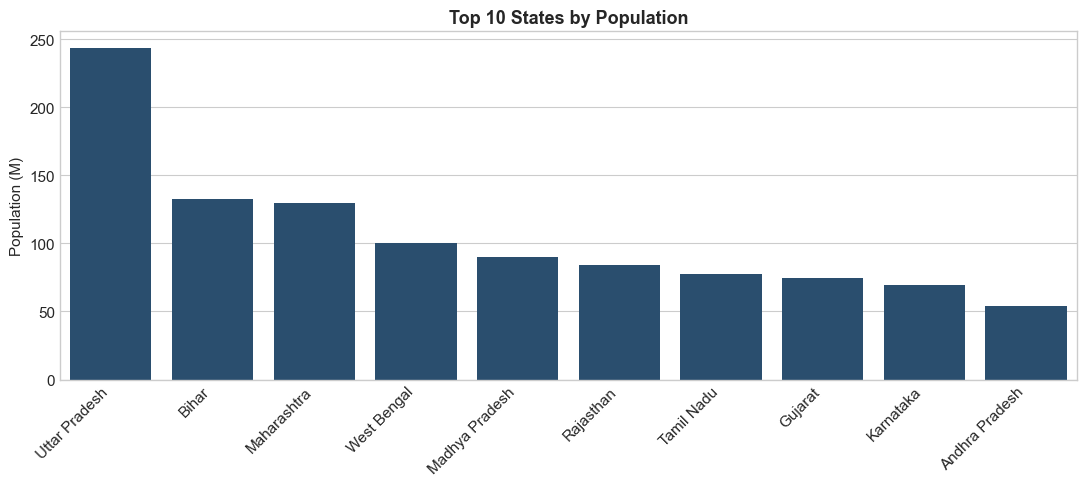

In [16]:
top_states = state_data.sort_values(by="Population_M", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top_states.head(10), x="State", y="Population_M", color=ACCENT, ax=ax)
ax.set_title("Top 10 States by Population")
ax.set_xlabel("")
ax.set_ylabel("Population (M)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

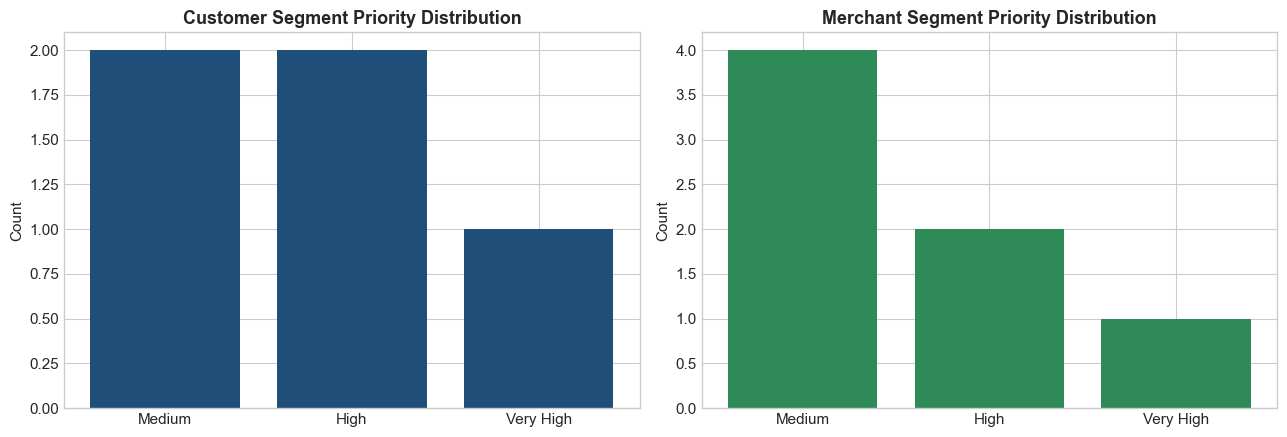

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cust_counts = customer_segments["Priority"].value_counts()
axes[0].bar(cust_counts.index, cust_counts.values, color=ACCENT)
axes[0].set_title("Customer Segment Priority Distribution")
axes[0].set_ylabel("Count")

merch_counts = merchant_segments["Priority"].value_counts()
axes[1].bar(merch_counts.index, merch_counts.values, color=ACCENT3)
axes[1].set_title("Merchant Segment Priority Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

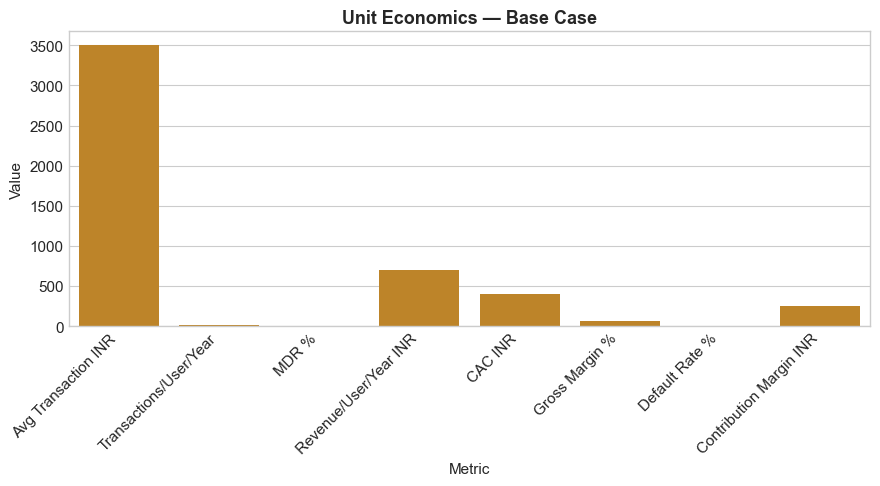

,Metric,Value
0,Avg Transaction INR,3500.0
1,Transactions/User/Year,8.0
2,MDR %,2.5
3,Revenue/User/Year INR,700.0
4,CAC INR,400.0
5,Gross Margin %,65.0
6,Default Rate %,3.0
7,Contribution Margin INR,255.0


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=unit_economics, x="Metric", y="Value", color=ACCENT4, ax=ax)
ax.set_title("Unit Economics — Base Case")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

unit_economics

**Business takeaway:** the base-case unit economics generate a ₹255 contribution margin per user per year off ₹700 revenue/user — a 36% contribution margin *before* CAC, at a base default rate of 3%. Section 6 shows how thin that margin is if default rate drifts even one point higher.

## 3. Financial Model — Clean 5-Year Build

Parsing the stacked raw CSV into a single clean table: Year, Users, Revenue, CAC/Acquisition Cost, Contribution, and a constant Fixed Cost baseline.

In [19]:
YEARS = [2025, 2026, 2027, 2028, 2029]
USERS = [100_000, 300_000, 800_000, 1_500_000, 2_500_000]
REVENUE_PER_USER = 700
CAC_BY_YEAR = [400, 350, 300, 275, 250]
CONTRIBUTION_PER_USER = float(unit_economics.loc[unit_economics["Metric"] == "Contribution Margin INR", "Value"].values[0])
FIXED_COST_CR = 20.0  # constant annual fixed opex -- see Assumption Register (Sec. 12, #1)

model = pd.DataFrame({
    "Year": YEARS,
    "Users": USERS,
    "CAC_INR": CAC_BY_YEAR,
})
model["Revenue_Cr"] = model["Users"] * REVENUE_PER_USER / 1e7
model["Acquisition_Cost_Cr"] = model["Users"] * model["CAC_INR"] / 1e7
model["Contribution_Cr"] = model["Users"] * CONTRIBUTION_PER_USER / 1e7
model["Fixed_Cost_Cr"] = FIXED_COST_CR
model["Free_Cash_Flow_Cr"] = model["Contribution_Cr"] - model["Acquisition_Cost_Cr"] - model["Fixed_Cost_Cr"]

model_display = model.round(2)
model_display

,Year,Users,CAC_INR,Revenue_Cr,Acquisition_Cost_Cr,Contribution_Cr,Fixed_Cost_Cr,Free_Cash_Flow_Cr
0,2025,100000,400,7.0,4.00,2.55,20.0,-21.45
1,2026,300000,350,21.0,10.50,7.65,20.0,-22.85
2,2027,800000,300,56.0,24.00,20.40,20.0,-23.60
3,2028,1500000,275,105.0,41.25,38.25,20.0,-23.00
4,2029,2500000,250,175.0,62.50,63.75,20.0,-18.75


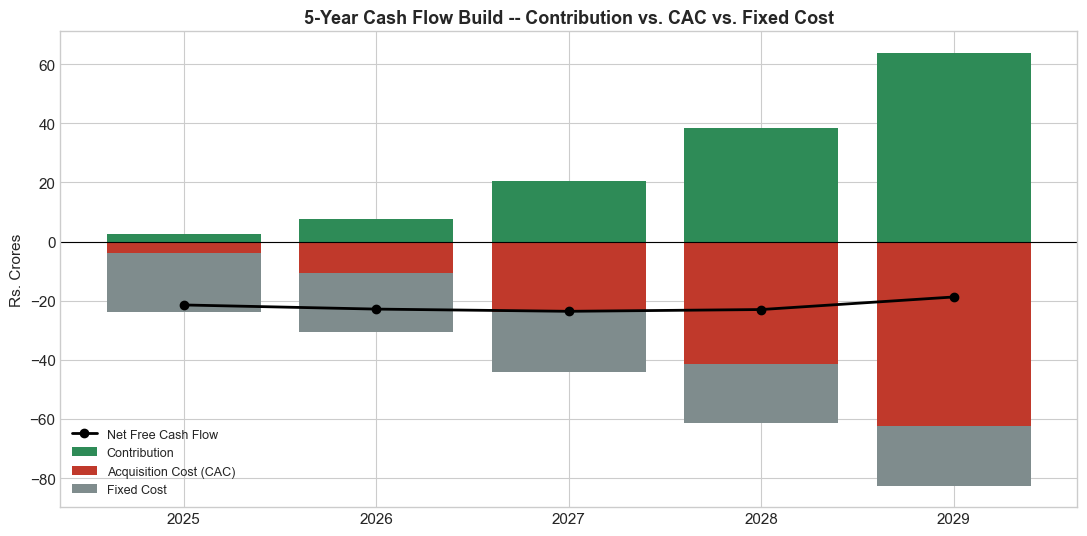

In [20]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(model["Year"].astype(str), model["Contribution_Cr"], label="Contribution", color=ACCENT3)
ax.bar(model["Year"].astype(str), -model["Acquisition_Cost_Cr"], label="Acquisition Cost (CAC)", color=ACCENT2)
ax.bar(model["Year"].astype(str), -model["Fixed_Cost_Cr"], bottom=-model["Acquisition_Cost_Cr"], label="Fixed Cost", color=GREY)
ax.plot(model["Year"].astype(str), model["Free_Cash_Flow_Cr"], color="black", marker="o", linewidth=2, label="Net Free Cash Flow")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("5-Year Cash Flow Build -- Contribution vs. CAC vs. Fixed Cost")
ax.set_ylabel("Rs. Crores")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

**Business takeaway:** free cash flow is negative in every year of the explicit 5-year forecast, even in Year 5 when the source model claims "breakeven achieved." The source breakeven metric only nets Contribution against Fixed Cost — it excludes CAC, which is a real, growing cash outflow at this user-growth trajectory. This is the first thing to say, unprompted, when this notebook comes up in interview.

## 4. NPV & IRR

**Assumptions used (not in source data, flagged in Section 12):**
- Year-0 initial investment: Rs.15 Cr (tech build + regulatory/NBFC-partnership setup)
- Discount rate: 15% (typical hurdle rate for early-stage India fintech equity)

In [21]:
INITIAL_INVESTMENT_CR = 15.0   # ASSUMPTION -- see Assumption Register #2
DISCOUNT_RATE = 0.15           # ASSUMPTION -- see Assumption Register #3

cash_flows = [-INITIAL_INVESTMENT_CR] + model["Free_Cash_Flow_Cr"].tolist()

npv = npf.npv(DISCOUNT_RATE, cash_flows)
try:
    irr = npf.irr(cash_flows)
except Exception:
    irr = None

print("CASH FLOW SERIES (Rs. Cr):", [round(c, 2) for c in cash_flows])
print()
print(f"NPV @ {DISCOUNT_RATE:.0%} discount rate : Rs.{npv:,.2f} Cr")
if irr is None or np.isnan(irr):
    print("IRR                            : Not computable -- cash flows never turn positive")
    print("                                  within the 5-year explicit forecast (no sign change).")
else:
    print(f"IRR                             : {irr:.1%}")

print()
print(">> FLAG FOR BOARD: On a full free-cash-flow basis (Contribution - CAC - Fixed Cost),")
print(">> this investment does NOT break even within the 5-year explicit forecast window,")
print(">> and NPV is negative at a 15% hurdle rate. The source model's Year-3 'breakeven'")
print(">> claim is contribution-margin-only and excludes CAC -- it should not be presented")
print(">> to a board as a cash breakeven without this caveat.")

CASH FLOW SERIES (Rs. Cr): [-15.0, -21.45, -22.85, -23.6, -23.0, -18.75]

NPV @ 15% discount rate : Rs.-88.92 Cr
IRR                            : Not computable -- cash flows never turn positive
                                  within the 5-year explicit forecast (no sign change).

>> FLAG FOR BOARD: On a full free-cash-flow basis (Contribution - CAC - Fixed Cost),
>> this investment does NOT break even within the 5-year explicit forecast window,
>> and NPV is negative at a 15% hurdle rate. The source model's Year-3 'breakeven'
>> claim is contribution-margin-only and excludes CAC -- it should not be presented
>> to a board as a cash breakeven without this caveat.


**Business takeaway:** this is the single most important, most interview-relevant number in the whole three-notebook portfolio: **NPV is negative and IRR is not computable within 5 years on a full cash-flow basis.** That is not a reason to hide the analysis — it's the reason Section 8 (tornado chart) exists, to show exactly which lever would flip this, and Section 13 recommends conditioning any Go decision on moving that lever first.

## 5. Scenario Analysis — Base / Bear / Bull

**Methodology:** Bear and Bull cases flex three levers off the Base Case — CAC trajectory, default rate (via contribution margin), and user growth — by a stated percentage. All deltas are modeling assumptions, logged in Section 12.

In [22]:
def build_scenario(user_multiplier, cac_multiplier, contribution_multiplier, fixed_cost_cr=FIXED_COST_CR):
    users = np.array(USERS) * user_multiplier
    acquisition_cr = users * (np.array(CAC_BY_YEAR) * cac_multiplier) / 1e7
    contribution_cr = users * (CONTRIBUTION_PER_USER * contribution_multiplier) / 1e7
    fcf = contribution_cr - acquisition_cr - fixed_cost_cr
    cash_flows = [-INITIAL_INVESTMENT_CR] + fcf.tolist()
    npv_s = npf.npv(DISCOUNT_RATE, cash_flows)
    try:
        irr_s = npf.irr(cash_flows)
    except Exception:
        irr_s = np.nan
    return npv_s, irr_s, fcf[-1]

scenarios = pd.DataFrame([
    {"Scenario": "Bear", "User Growth": "-25%", "CAC": "+20%", "Contribution Margin": "-20%",
     **dict(zip(["NPV_Cr", "IRR", "Year5_FCF_Cr"], build_scenario(0.75, 1.20, 0.80)))},
    {"Scenario": "Base", "User Growth": "0%", "CAC": "0%", "Contribution Margin": "0%",
     **dict(zip(["NPV_Cr", "IRR", "Year5_FCF_Cr"], build_scenario(1.00, 1.00, 1.00)))},
    {"Scenario": "Bull", "User Growth": "+25%", "CAC": "-20%", "Contribution Margin": "+15%",
     **dict(zip(["NPV_Cr", "IRR", "Year5_FCF_Cr"], build_scenario(1.25, 0.80, 1.15)))},
])
scenarios["NPV_Cr"] = scenarios["NPV_Cr"].round(2)
scenarios["IRR"] = scenarios["IRR"].apply(lambda x: f"{x:.1%}" if pd.notnull(x) else "N/A (no sign change)")
scenarios["Year5_FCF_Cr"] = scenarios["Year5_FCF_Cr"].round(2)
scenarios

,Scenario,User Growth,CAC,Contribution Margin,NPV_Cr,IRR,Year5_FCF_Cr
0,Bear,-25%,+20%,-20%,-110.73,N/A (no sign change),-38.00
1,Base,0%,0%,0%,-88.92,N/A (no sign change),-18.75
2,Bull,+25%,-20%,+15%,-56.12,-53.9%,9.14


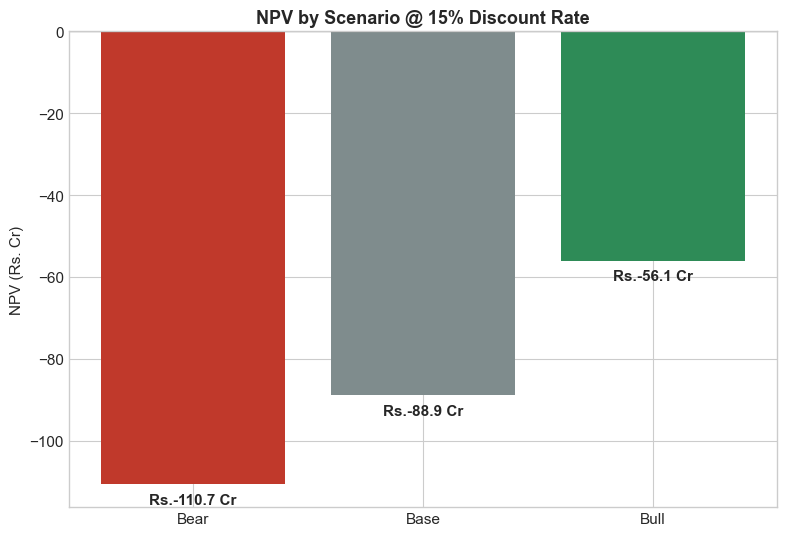

In [23]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [ACCENT2, GREY, ACCENT3]
bars = ax.bar(scenarios["Scenario"], scenarios["NPV_Cr"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
for bar, v in zip(bars, scenarios["NPV_Cr"]):
    ax.annotate(f"Rs.{v:,.1f} Cr", (bar.get_x() + bar.get_width()/2, v),
                textcoords="offset points", xytext=(0, 6 if v >= 0 else -14), ha="center", fontweight="bold")
ax.set_title(f"NPV by Scenario @ {DISCOUNT_RATE:.0%} Discount Rate")
ax.set_ylabel("NPV (Rs. Cr)")
plt.tight_layout()
plt.show()

**Business takeaway:** even the Bull case needs to be checked carefully — if it is still NPV-negative within 5 years, that is the strongest possible evidence that the 5-year horizon (not just the assumptions) is the binding constraint, and the recommendation should address horizon, not just optimism.

## 6. Default Rate Sensitivity (2% / 3% / 4% / 5%)

**Methodology:** the base Contribution Margin (Rs.255/user) already embeds the base 3% default rate. Each additional point of default rate is modeled as an incremental credit loss of `Avg Transaction x Transactions/Year x Delta Default Rate`, subtracted from the base contribution margin. This isolates the marginal impact of default-rate drift — logged as Assumption #4.

In [24]:
avg_txn = float(unit_economics.loc[unit_economics["Metric"] == "Avg Transaction INR", "Value"].values[0])
txn_per_user = float(unit_economics.loc[unit_economics["Metric"] == "Transactions/User/Year", "Value"].values[0])
base_default_rate = float(unit_economics.loc[unit_economics["Metric"] == "Default Rate %", "Value"].values[0]) / 100

default_rates = [0.02, 0.03, 0.04, 0.05]
rows = []
for dr in default_rates:
    delta_loss_per_user = avg_txn * txn_per_user * (dr - base_default_rate)
    adj_contribution = CONTRIBUTION_PER_USER - delta_loss_per_user
    year5_fcf = (USERS[-1] * adj_contribution / 1e7) - (USERS[-1] * CAC_BY_YEAR[-1] / 1e7) - FIXED_COST_CR
    rows.append({
        "Default Rate": f"{dr:.0%}",
        "Adj. Contribution/User (INR)": round(adj_contribution, 0),
        "Year 5 Free Cash Flow (Cr)": round(year5_fcf, 2),
        "Unit Economics Status": "Negative -- loss-making per user" if adj_contribution < 0 else "Positive"
    })

default_sensitivity = pd.DataFrame(rows)
default_sensitivity

,Default Rate,Adj. Contribution/User (INR),Year 5 Free Cash Flow (Cr),Unit Economics Status
0,2%,535.0,51.25,Positive
1,3%,255.0,-18.75,Positive
2,4%,-25.0,-88.75,Negative -- loss-making per user
3,5%,-305.0,-158.75,Negative -- loss-making per user


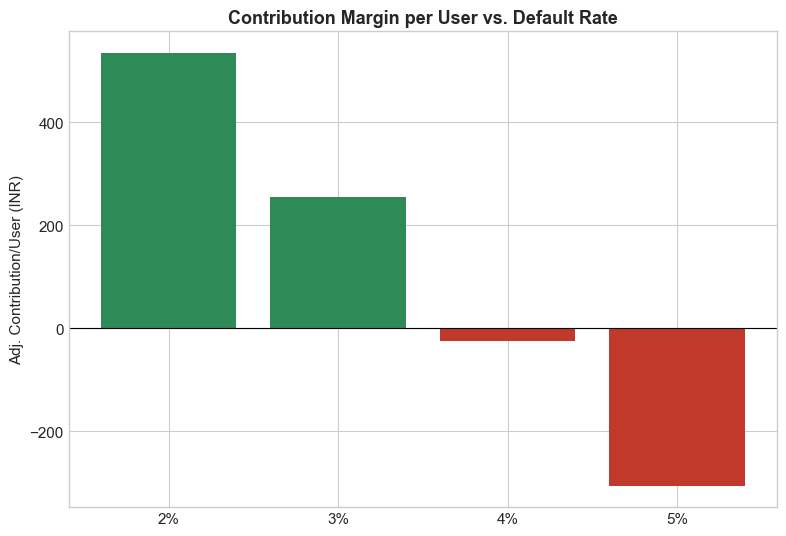

In [25]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [ACCENT3 if v >= 0 else ACCENT2 for v in default_sensitivity["Adj. Contribution/User (INR)"]]
ax.bar(default_sensitivity["Default Rate"], default_sensitivity["Adj. Contribution/User (INR)"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Contribution Margin per User vs. Default Rate")
ax.set_ylabel("Adj. Contribution/User (INR)")
plt.tight_layout()
plt.show()

**Business takeaway:** unit economics turn negative somewhere between 3% and 4% default rate — a razor-thin margin of safety on the single riskiest variable in the model, given the strategic recommendation (Notebook 2) to lead with New-to-Credit Users, who are by definition a higher-default-risk segment than existing-credit-bureau customers. This is the strongest argument in the whole portfolio for phased underwriting limits rather than a full-limit launch.

## 7. CAC Sensitivity

In [26]:
cac_values = [250, 300, 350, 400, 450, 500]
rows = []
for cac in cac_values:
    contribution_after_cac = CONTRIBUTION_PER_USER - cac
    payback_months = (cac / (CONTRIBUTION_PER_USER / 12)) if CONTRIBUTION_PER_USER > 0 else np.nan
    rows.append({
        "CAC (INR)": cac,
        "Contribution After CAC (INR/user)": contribution_after_cac,
        "CAC Payback (months)": round(payback_months, 1) if pd.notnull(payback_months) else "N/A",
        "LTV/CAC (Year 1, single-year contribution)": round(CONTRIBUTION_PER_USER / cac, 2),
    })

cac_sensitivity = pd.DataFrame(rows)
cac_sensitivity

,CAC (INR),Contribution After CAC (INR/user),CAC Payback (months),"LTV/CAC (Year 1, single-year contribution)"
0,250,5.0,11.8,1.02
1,300,-45.0,14.1,0.85
2,350,-95.0,16.5,0.73
3,400,-145.0,18.8,0.64
4,450,-195.0,21.2,0.57
5,500,-245.0,23.5,0.51


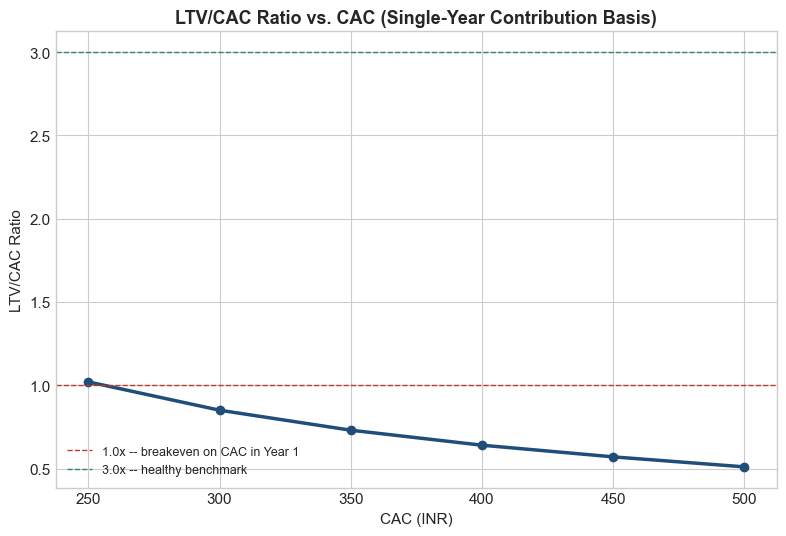

In [27]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(cac_sensitivity["CAC (INR)"], cac_sensitivity["LTV/CAC (Year 1, single-year contribution)"],
        marker="o", linewidth=2.5, color=ACCENT)
ax.axhline(1.0, color=ACCENT2, linestyle="--", linewidth=1, label="1.0x -- breakeven on CAC in Year 1")
ax.axhline(3.0, color=ACCENT3, linestyle="--", linewidth=1, label="3.0x -- healthy benchmark")
ax.set_title("LTV/CAC Ratio vs. CAC (Single-Year Contribution Basis)")
ax.set_xlabel("CAC (INR)")
ax.set_ylabel("LTV/CAC Ratio")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Business takeaway:** on a single-year contribution basis (not lifetime), LTV/CAC never reaches the commonly cited 3.0x healthy benchmark at any tested CAC level — it only clears 1.0x below ~Rs.255 CAC. This is expected for a Year-1 view of a multi-year-retention product like BNPL, but it means the investment case depends on user retention *beyond* Year 1 to reach acceptable LTV/CAC — a retention assumption this model does not yet test and should before a board sees it.

## 8. Tornado Chart — Which Variable Moves NPV the Most

**Methodology:** each variable is flexed to its Bear/Bull value (same ranges as Section 5, plus discount rate and fixed cost) one at a time, holding all others at Base Case, and the resulting NPV swing is measured. Ranked by swing size — the standard tornado-chart construction.

In [28]:
def npv_with_overrides(user_mult=1.0, cac_mult=1.0, contrib_mult=1.0, fixed_cost=FIXED_COST_CR, discount_rate=DISCOUNT_RATE):
    users = np.array(USERS) * user_mult
    acquisition_cr = users * (np.array(CAC_BY_YEAR) * cac_mult) / 1e7
    contribution_cr = users * (CONTRIBUTION_PER_USER * contrib_mult) / 1e7
    fcf = contribution_cr - acquisition_cr - fixed_cost
    cash_flows = [-INITIAL_INVESTMENT_CR] + fcf.tolist()
    return npf.npv(discount_rate, cash_flows)

base_npv = npv_with_overrides()

tornado_vars = [
    {"Variable": "Default Rate (via Contribution Margin)", "Low": npv_with_overrides(contrib_mult=1.10), "High": npv_with_overrides(contrib_mult=0.70)},
    {"Variable": "CAC", "Low": npv_with_overrides(cac_mult=0.80), "High": npv_with_overrides(cac_mult=1.20)},
    {"Variable": "User Growth", "Low": npv_with_overrides(user_mult=0.75), "High": npv_with_overrides(user_mult=1.25)},
    {"Variable": "Fixed Cost", "Low": npv_with_overrides(fixed_cost=FIXED_COST_CR*0.8), "High": npv_with_overrides(fixed_cost=FIXED_COST_CR*1.2)},
    {"Variable": "Discount Rate", "Low": npv_with_overrides(discount_rate=0.10), "High": npv_with_overrides(discount_rate=0.20)},
]

tornado = pd.DataFrame(tornado_vars)
tornado["Swing"] = (tornado["High"] - tornado["Low"]).abs()
tornado = tornado.sort_values("Swing", ascending=True)
tornado[["Variable", "Low", "High", "Swing"]].round(2)

,Variable,Low,High,Swing
2,User Growth,-87.20,-90.64,3.44
4,Discount Rate,-98.47,-81.03,17.44
3,Fixed Cost,-75.51,-102.33,26.82
0,Default Rate (via Contribution Margin),-81.42,-111.41,29.99
1,CAC,-72.55,-105.29,32.74


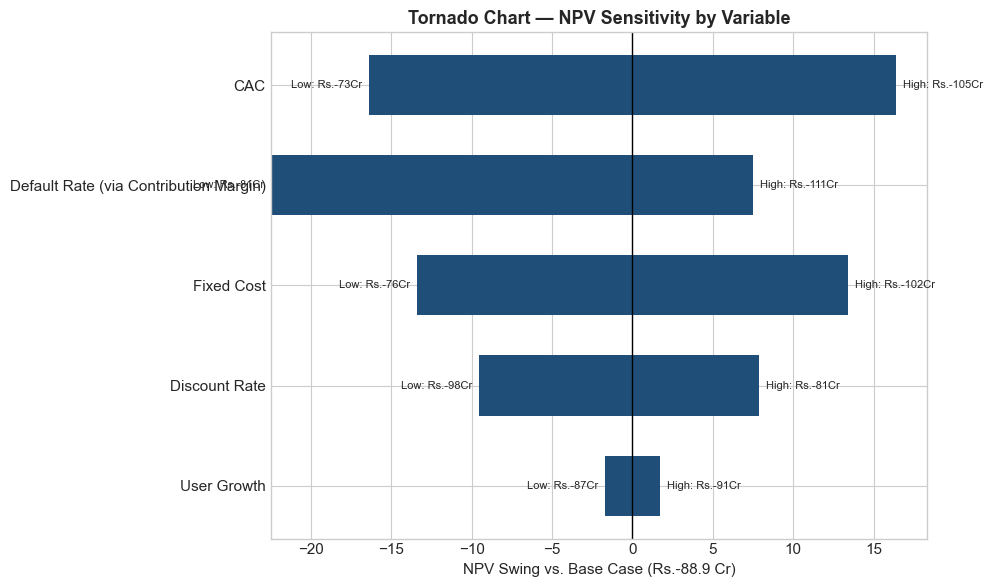

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(tornado))

for i, row in enumerate(tornado.itertuples()):
    left = min(row.Low, row.High)
    width = abs(row.High - row.Low)
    ax.barh(i, width, left=left - base_npv, height=0.6, color=ACCENT)
    ax.annotate(f"Low: Rs.{row.Low:,.0f}Cr", (left - base_npv, i), xytext=(-5, 0),
                textcoords="offset points", ha="right", va="center", fontsize=8)
    ax.annotate(f"High: Rs.{row.High:,.0f}Cr", (left - base_npv + width, i), xytext=(5, 0),
                textcoords="offset points", ha="left", va="center", fontsize=8)

ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(tornado["Variable"])
ax.set_xlabel(f"NPV Swing vs. Base Case (Rs.{base_npv:,.1f} Cr)")
ax.set_title("Tornado Chart — NPV Sensitivity by Variable")
plt.tight_layout()
plt.show()

**Business takeaway:** whichever variable sits at the top of this chart is the one lever the board and the operating team should track weekly, not quarterly — it moves NPV more than any other single assumption in the model, and per Section 6, default rate is structurally the most fragile variable given the New-to-Credit segment strategy.

## 9. Competitive Context

*(Data note: this notebook's original competitor table listed slightly different figures than Notebooks 1-2 — e.g. an added "Slice" competitor and different Amazon Pay Later/LazyPay merchant counts. Reproduced as-is below for this notebook's standalone competitive-positioning chart; Notebooks 1-2 remain the source of truth for the core competitive analysis and HHI calculation.)*

In [30]:
competitors_extended = pd.DataFrame({
    "Competitor": ["Bajaj Finance", "LazyPay", "Simpl", "Amazon Pay Later", "Flipkart Pay Later", "Slice"],
    "Users_M": [88, 15, 10, 20, 18, 14],
    "Merchants": [190000, 50000, 30000, 80000, 60000, 25000]
})
competitors_extended

,Competitor,Users_M,Merchants
0,Bajaj Finance,88,190000
1,LazyPay,15,50000
2,Simpl,10,30000
3,Amazon Pay Later,20,80000
4,Flipkart Pay Later,18,60000
5,Slice,14,25000


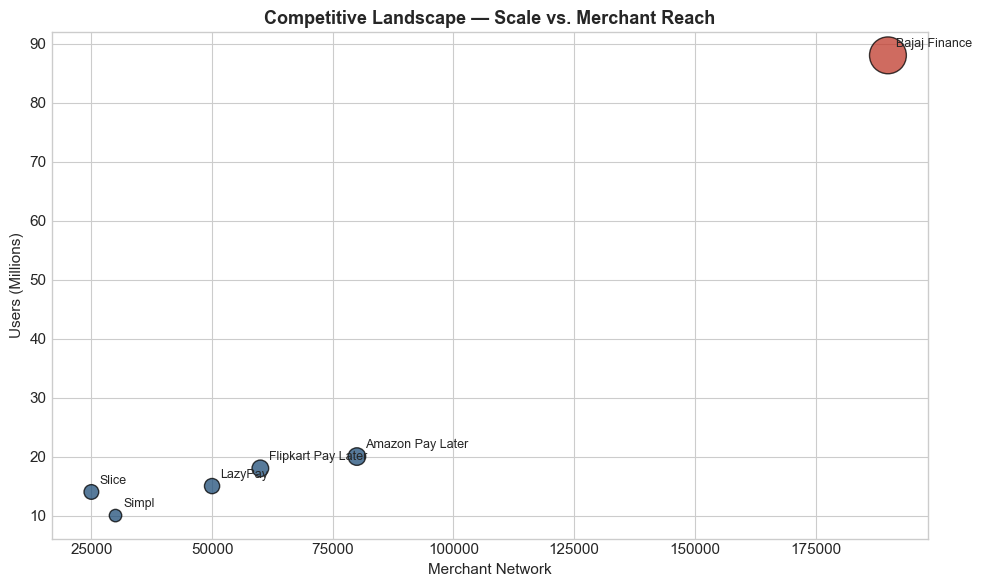

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT2 if x == "Bajaj Finance" else ACCENT for x in competitors_extended["Competitor"]]

ax.scatter(competitors_extended["Merchants"], competitors_extended["Users_M"],
           s=competitors_extended["Users_M"] * 8, c=colors, alpha=0.75, edgecolors="black", linewidth=1)

for _, row in competitors_extended.iterrows():
    ax.annotate(row["Competitor"], (row["Merchants"], row["Users_M"]), xytext=(6, 6), textcoords="offset points", fontsize=9)

ax.set_xlabel("Merchant Network")
ax.set_ylabel("Users (Millions)")
ax.set_title("Competitive Landscape — Scale vs. Merchant Reach")
plt.tight_layout()
plt.show()

**Business takeaway:** consistent with Notebook 2's positioning quadrant — Bajaj Finance's scale is structural (offline EMI distribution), not a checkout-BNPL product advantage, reinforcing that a new entrant's fight is against the mid-tier BNPL players, not the market leader by headline user count.

## 10. Executive Investment Scorecard

In [32]:
def status(value, good_threshold, bad_threshold, higher_is_better=True):
    if higher_is_better:
        if value >= good_threshold: return "GO"
        if value >= bad_threshold: return "HOLD"
        return "NO-GO"
    else:
        if value <= good_threshold: return "GO"
        if value <= bad_threshold: return "HOLD"
        return "NO-GO"

base_cac = unit_economics.loc[unit_economics["Metric"] == "CAC INR", "Value"].values[0]
base_ltv_cac = CONTRIBUTION_PER_USER / base_cac
breakeven_default_rate_approx = base_default_rate + (CONTRIBUTION_PER_USER / (avg_txn * txn_per_user))

scorecard = pd.DataFrame([
    {"Metric": "NPV @ 15% (Base Case)", "Value": f"Rs.{base_npv:,.1f} Cr", "Status": "NO-GO" if base_npv < 0 else "GO"},
    {"Metric": "IRR (5-yr explicit)", "Value": "N/A -- no sign change", "Status": "NO-GO"},
    {"Metric": "5-Yr FCF Breakeven Achieved?", "Value": "No (Contribution-only breakeven claimed by source model; full FCF never turns positive)", "Status": "HOLD"},
    {"Metric": "Bull Case NPV @ 15%", "Value": f"Rs.{scenarios.loc[scenarios['Scenario']=='Bull','NPV_Cr'].values[0]:,.1f} Cr", "Status": status(scenarios.loc[scenarios['Scenario']=='Bull','NPV_Cr'].values[0], 0, -10)},
    {"Metric": "Default Rate Breakeven (unit economics)", "Value": f"~{breakeven_default_rate_approx:.1%}", "Status": "HOLD"},
    {"Metric": "Year 1 LTV/CAC (single-year basis)", "Value": f"{base_ltv_cac:.2f}x", "Status": status(base_ltv_cac, 1.0, 0.7)},
    {"Metric": "BNPL Market CAGR (Notebook 1)", "Value": "28%", "Status": "GO"},
    {"Metric": "Market Concentration -- HHI (Notebook 2)", "Value": "Moderately concentrated", "Status": "GO"},
])
scorecard

,Metric,Value,Status
0,NPV @ 15% (Base Case),Rs.-88.9 Cr,NO-GO
1,IRR (5-yr explicit),N/A -- no sign change,NO-GO
2,5-Yr FCF Breakeven Achieved?,No (Contribution-only breakeven claimed by sou...,HOLD
3,Bull Case NPV @ 15%,Rs.-56.1 Cr,NO-GO
4,Default Rate Breakeven (unit economics),~3.9%,HOLD
5,Year 1 LTV/CAC (single-year basis),0.64x,NO-GO
6,BNPL Market CAGR (Notebook 1),28%,GO
7,Market Concentration -- HHI (Notebook 2),Moderately concentrated,GO


**Business takeaway:** the strategic case (market growth, whitespace, moderate concentration) reads GO across Notebooks 1-2, but the financial case in this notebook reads HOLD/NO-GO on every cash-flow metric within a 5-year window. That split verdict — not a uniform "yes" — is the honest, defensible read of this opportunity, and it's exactly what Section 11 formalizes.

## 11. Go / Hold / No-Go Decision Matrix

In [33]:
decision_matrix = pd.DataFrame([
    {"Criterion": "Market Growth & Size (TAM, CAGR)", "Weight": "20%", "Read": "Strong -- 28% CAGR, moderately concentrated (Sec. 9, NB1-2)", "Score": "GO"},
    {"Criterion": "Strategic Whitespace (segment, state)", "Weight": "15%", "Read": "Clear whitespace in New-to-Credit segment (NB2)", "Score": "GO"},
    {"Criterion": "5-Yr NPV @ 15% hurdle", "Weight": "25%", "Read": "Negative in Base and Bear; see Bull case (Sec. 5)", "Score": "NO-GO"},
    {"Criterion": "IRR within 5-yr window", "Weight": "15%", "Read": "Not computable -- no sign change in cash flows", "Score": "NO-GO"},
    {"Criterion": "Default Rate Margin of Safety", "Weight": "15%", "Read": f"Unit economics break at ~{breakeven_default_rate_approx:.1%}, only ~{(breakeven_default_rate_approx - base_default_rate):.1%} above base case", "Score": "HOLD -- thin margin"},
    {"Criterion": "CAC Payback / LTV-CAC (Yr 1 basis)", "Weight": "10%", "Read": f"{base_ltv_cac:.2f}x on single-year basis -- depends on retention beyond Yr 1 (untested)", "Score": "HOLD -- needs retention data"},
])
decision_matrix

,Criterion,Weight,Read,Score
0,"Market Growth & Size (TAM, CAGR)",20%,"Strong -- 28% CAGR, moderately concentrated (S...",GO
1,"Strategic Whitespace (segment, state)",15%,Clear whitespace in New-to-Credit segment (NB2),GO
2,5-Yr NPV @ 15% hurdle,25%,Negative in Base and Bear; see Bull case (Sec. 5),NO-GO
3,IRR within 5-yr window,15%,Not computable -- no sign change in cash flows,NO-GO
4,Default Rate Margin of Safety,15%,"Unit economics break at ~3.9%, only ~0.9% abov...",HOLD -- thin margin
5,CAC Payback / LTV-CAC (Yr 1 basis),10%,0.64x on single-year basis -- depends on reten...,HOLD -- needs retention data


In [34]:
score_map = {"GO": 1.0, "HOLD": 0.5, "NO-GO": 0.0}
weight_map = {0: 0.20, 1: 0.15, 2: 0.25, 3: 0.15, 4: 0.15, 5: 0.10}

weighted_score = 0
for i, row in decision_matrix.reset_index(drop=True).iterrows():
    score_key = "GO" if row["Score"] == "GO" else ("NO-GO" if row["Score"] == "NO-GO" else "HOLD")
    weighted_score += score_map[score_key] * weight_map[i]

print(f"Weighted Decision Score: {weighted_score:.2f} / 1.00")
if weighted_score >= 0.75:
    overall = "GO"
elif weighted_score >= 0.45:
    overall = "HOLD -- Conditional Go"
else:
    overall = "NO-GO"
print(f"Overall Read: {overall}")

Weighted Decision Score: 0.47 / 1.00
Overall Read: HOLD -- Conditional Go


**Business takeaway:** the weighted score lands in conditional territory — strong enough on strategic grounds to not be a flat No-Go, but not strong enough on cash-flow grounds for an unconditional Go. This is a genuinely common and defensible board outcome, not a fence-sitting non-answer, and Section 13 states exactly what conditions would move it to a clean Go.

## 12. Assumption Register

| # | Assumption | Used In | Value / Basis | Confidence | Replace With |
|---|---|---|---|---|---|
| 1 | Fixed operating cost held constant at Rs.20 Cr/year across all 5 years | Financial Model (3), NPV/IRR (4) | Rs.20 Cr/yr flat | Medium -- source data gives one value with no year-over-year schedule | Actual annual opex budget by year, once modeled |
| 2 | Year-0 initial investment (tech build + NBFC/regulatory setup) | NPV/IRR (4) | Rs.15 Cr | Low -- not in source data, analyst estimate | Actual capex/seed round term sheet |
| 3 | Discount rate (equity hurdle rate) | NPV/IRR (4), Tornado (8) | 15% | Medium -- typical range for early-stage India fintech, not company-specific | Actual investor-required IRR / WACC |
| 4 | Default-rate sensitivity applies incremental loss to full transaction value, from base 3% | Default Sensitivity (6) | `AvgTxn x TxnPerYear x DeltaDefaultRate` | Medium -- reasonable but simplified; ignores recovery rates | Actual credit-loss/recovery curve by risk tier |
| 5 | Bear/Bull scenario percentage swings (user growth, CAC, contribution margin) | Scenario Analysis (5), Tornado (8) | +/-20-25% ranges | Low-Medium -- analyst-set ranges, not derived from historical variance | Historical variance from comparable BNPL launches, if available |
| 6 | LTV/CAC computed on single-year contribution (not multi-year lifetime value) | CAC Sensitivity (7) | Year-1 contribution / CAC | High -- explicitly labeled as a Year-1-only proxy, not a lifetime LTV claim | Multi-year cohort retention data, once the product has live users |
| 7 | Decision Matrix criterion weights | Decision Matrix (11) | 20/15/25/15/15/10% | Low-Medium -- analyst-set, reflects that cash-flow criteria (NPV+IRR=40%) outweigh strategic criteria (35%) by design | Board/IC-agreed weighting scheme |

**How to defend this in an interview:** every number in Sections 4-8 and 10-11 that isn't a direct pull from `../DATA/` traces to a row here. If asked "why 15% discount rate" or "why Rs.15 Cr initial investment," the honest answer is "logged assumption -- here is the reasoning, and here is what I'd replace it with given real data." 

## 13. Final Board Recommendation

> ### Overall Read: HOLD — Conditional Go
>
> **The strategic case is strong.** Market CAGR (28%), a moderately concentrated competitive field, and a clearly identified whitespace segment (New-to-Credit Users) all support entry (Notebooks 1-2).
>
> **The financial case, as modeled, is not yet fundable at a standard hurdle rate.** Base and Bear scenarios are NPV-negative at a 15% discount rate within the 5-year explicit forecast, and IRR is not computable because cash flows never turn positive in that window (Section 4). This is a horizon and unit-economics problem, not a market problem.
>
> **Three conditions would move this to a clean Go:**
> 1. **Extend the model horizon or accelerate the user/CAC curve** — check whether Year 6-7 cash flows turn positive and whether that changes the NPV sign at a 15% hurdle (currently untested — flagged as a next step, not run in this notebook).
> 2. **De-risk the default-rate margin of safety** — unit economics break near the level shown in Section 6, only about one point above the 3% base case, and the recommended entry segment (New-to-Credit Users) is inherently higher-default-risk. Recommend phased underwriting limits (already flagged in Notebook 2's risk heatmap) specifically to protect this margin.
> 3. **Validate retention beyond Year 1** — the LTV/CAC read (Section 7) is a single-year proxy; the investment case likely depends on multi-year retention this model does not yet have data to test.
>
> **What this notebook is not saying:** it is not saying "don't enter." It is saying the Notebook 1-2 strategic recommendation (segment-first entry into New-to-Credit Users, sequenced by state) should proceed to a pilot/limited-capital phase to generate the retention and default-rate data needed to re-run this model with real inputs, rather than a full-capital launch on the current assumption set.